In [3]:
# =============================
# 1. Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [4]:
# =============================
# 2. Load and prepare data
# =============================
PROJECT_ROOT = Path().resolve().parent
data_path = PROJECT_ROOT / "data" / "processed" / "iberia.csv"

df_pt = pd.read_csv(
    data_path,
    parse_dates=["DateUTC"]
)

# Keep relevant columns
df_pt = df_pt[["DateUTC", "Value"]].copy()

# Sort and set index
df_pt = df_pt.sort_values("DateUTC")
df_pt = df_pt.set_index("DateUTC")

# Aggregate duplicates (important)
df_pt = df_pt.groupby(df_pt.index)["Value"].mean().to_frame()

# Ensure hourly frequency
df_pt = df_pt.asfreq("h")

# Fill missing values
df_pt["Value"] = df_pt["Value"].interpolate(method="time")

print("Data ready:", df_pt.shape)

Data ready: (26305, 1)


In [9]:
# =============================
# 3. Train / Test split
# =============================
df_pt = df_pt.sort_index()

train = df_pt.loc[:"2025-07-31"].copy()
test  = df_pt.loc["2025-08-01":].copy()

print("Train:", train.shape)
print("Test:", test.shape)
print("Test period:", test.index.min(), "→", test.index.max())

Train: (24841, 1)
Test: (1464, 1)
Test period: 2025-08-01 00:00:00 → 2025-09-30 23:00:00


In [10]:
# =============================
# 4. Fit SARIMA model
# =============================
model = SARIMAX(
    train["Value"],
    order=(1, 1, 1),              # non-seasonal
    seasonal_order=(1, 1, 1, 24), # daily seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(disp=False)

print(fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                24841
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood             -170825.078
Date:                            Tue, 21 Apr 2026   AIC                         341660.156
Time:                                    19:05:59   BIC                         341700.747
Sample:                                09-30-2022   HQIC                        341673.299
                                     - 07-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3901      0.003    144.964      0.000       0.385       0.395
ma.L1          0.2364      0.002   

In [11]:
# =============================
# 5. Forecast full test period
# =============================
forecast = fit.forecast(steps=len(test))

# Align forecast index with test
forecast = pd.Series(forecast.values, index=test.index)

In [12]:
# =============================
# 6. Evaluation
# =============================
df_eval = pd.DataFrame({
    "actual": test["Value"],
    "forecast": forecast
}).dropna()

mae = mean_absolute_error(df_eval["actual"], df_eval["forecast"])
rmse = np.sqrt(mean_squared_error(df_eval["actual"], df_eval["forecast"]))
mape = np.mean(np.abs((df_eval["actual"] - df_eval["forecast"]) / df_eval["actual"])) * 100

print("\n--- SARIMA Results ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


--- SARIMA Results ---
MAE:  981.34
RMSE: 1217.54
MAPE: 5.87%


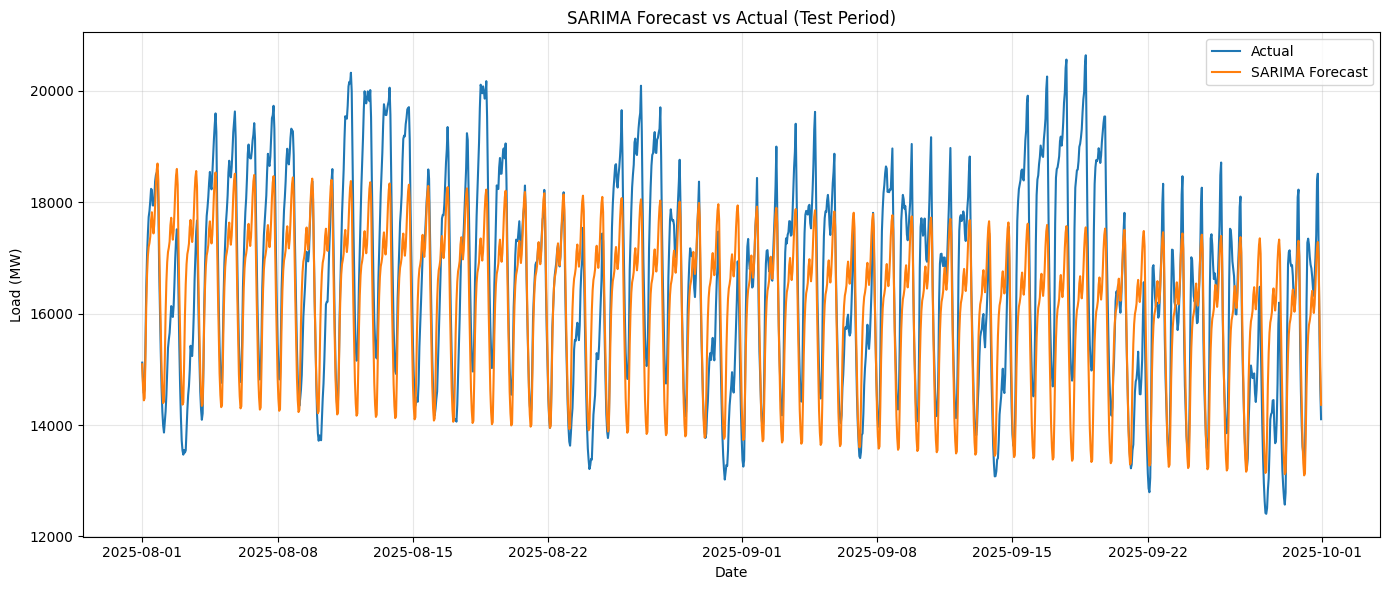

In [13]:
# =============================
# 7. Plot results
# =============================
plt.figure(figsize=(14,6))

plt.plot(test.index, test["Value"], label="Actual")
plt.plot(test.index, forecast, label="SARIMA Forecast")

plt.title("SARIMA Forecast vs Actual (Test Period)")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
# =============================
# 8. 24-hour forecast example
# =============================
forecast_24h = fit.forecast(steps=24)

# Align with first 24h of test
actual_24h = test["Value"].iloc[:24]
forecast_24h = pd.Series(forecast_24h.values, index=actual_24h.index)

df_eval_24h = pd.DataFrame({
    "actual": actual_24h,
    "forecast": forecast_24h
}).dropna()

mae_24 = mean_absolute_error(df_eval_24h["actual"], df_eval_24h["forecast"])
rmse_24 = np.sqrt(mean_squared_error(df_eval_24h["actual"], df_eval_24h["forecast"]))
mape_24 = np.mean(np.abs((df_eval_24h["actual"] - df_eval_24h["forecast"]) / df_eval_24h["actual"])) * 100

print("\n--- 24h Forecast ---")
print(f"MAE:  {mae_24:.2f}")
print(f"RMSE: {rmse_24:.2f}")
print(f"MAPE: {mape_24:.2f}%")


--- 24h Forecast ---
MAE:  339.48
RMSE: 381.10
MAPE: 1.96%


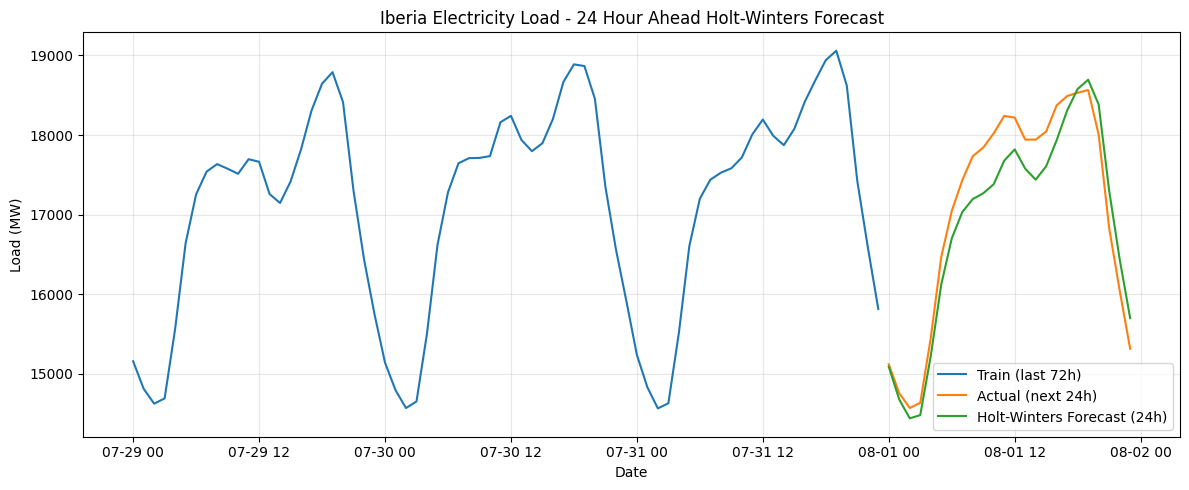

In [15]:
# -----------------------------
# 6. Plot 24h forecast
# -----------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    train.index[-72:],
    train["Value"].iloc[-72:],
    label="Train (last 72h)"
)

plt.plot(
    actual_24h.index,
    actual_24h,
    label="Actual (next 24h)"
)

plt.plot(
    actual_24h.index,
    forecast_24h,
    label="Holt-Winters Forecast (24h)"
)

plt.title("Iberia Electricity Load - 24 Hour Ahead Holt-Winters Forecast")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/holt_winters_forecast.png", dpi=300)
plt.show()